# 02 Risk Ranking Validation
## 위험 순위 검증

이 노트북은 risk score가 고객을 위험도 순서로 일관되게 정렬하는지 확인한다.

확률 보정이 아니라 manual review 우선순위가 목적이므로, score bucket과 decile별 실제 default concentration을 본다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SAMPLE_DIR = DATA_DIR / "sample"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def read_table(name):
    path = TABLE_DIR / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def as_percent(series, digits=2):
    return (series.astype(float) * 100).round(digits)


## Decile separation
### 분위 구간별 위험 분리

D1은 score 상위 10%, D10은 score 하위 10%이다. 위험 점수가 유효하다면 D1에서 default rate가 높고 D10으로 갈수록 낮아져야 한다.


,risk_decile_label,customers,observed_defaults,avg_risk_score,default_rate_pct
0,D1\nHighest,45892,44326,0.9642,96.59
1,D2,45891,36850,0.8048,80.30
2,D3,45891,23940,0.5255,52.17
3,D4,45892,10123,0.2156,22.06
4,D5,45891,2549,0.0543,5.55
5,D6,45891,662,0.0146,1.44
6,D7,45892,219,0.0053,0.48
7,D8,45891,96,0.0025,0.21
8,D9,45891,45,0.0014,0.10
9,D10\nLowest,45891,18,0.0007,0.04


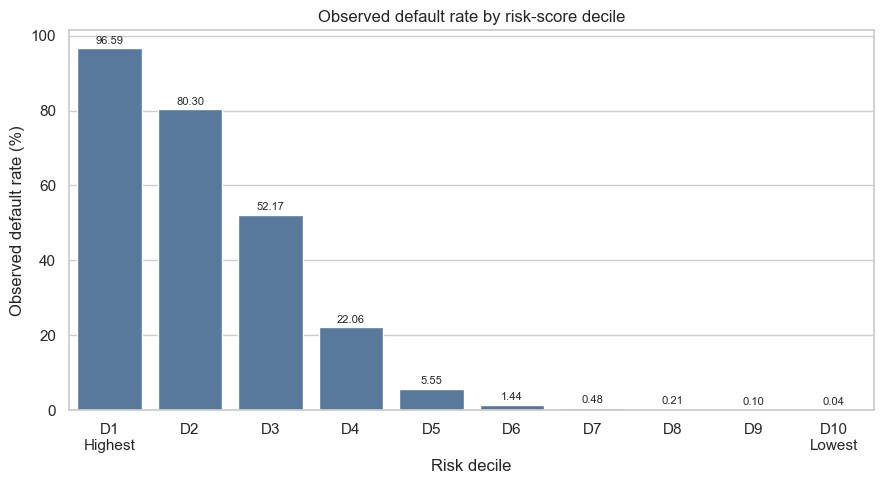

C:\Users\박동하\Documents\Codex\2026-05-04\files-mentioned-by-the-user-amex\amex-credit-risk-portfolio-public\outputs\figures\risk_bucket_decile_validation.png


In [2]:
decile = read_table("risk_decile_summary.csv")
decile["default_rate_pct"] = as_percent(decile["observed_default_rate"])
decile["avg_risk_score"] = decile["avg_risk_score"].round(4)
display(decile[["risk_decile_label", "customers", "observed_defaults", "avg_risk_score", "default_rate_pct"]])

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=decile, x="risk_decile_label", y="default_rate_pct", color="#4C78A8", ax=ax)
ax.set_title("Observed default rate by risk-score decile")
ax.set_xlabel("Risk decile")
ax.set_ylabel("Observed default rate (%)")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
path = save_figure("risk_bucket_decile_validation.png")
plt.show()
print(path)


D1 default rate는 96.59%, D10 default rate는 0.04%이다. 점수가 높은 구간일수록 실제 default가 집중되어 있어, 이 score는 review priority ranking signal로 사용할 수 있다.


## Risk band monitoring
### 위험 밴드 모니터링

운영에서는 decile보다 더 단순한 risk band가 필요하다. 각 band의 고객 수, default rate, capture share를 확인한다.


,risk_band,customer_count,default_count,default_rate_pct,capture_share_pct,avg_risk_score,score_month,model_version
0,Critical,4589,4588,99.98,3.86,0.997642,2018-03-31,best_equal_8models
1,High Risk,18356,18153,98.89,15.28,0.986248,2018-03-31,best_equal_8models
2,Watchlist,22946,21584,94.06,18.16,0.939868,2018-03-31,best_equal_8models
3,Standard,413022,74503,18.04,62.70,0.180522,2018-03-31,best_equal_8models


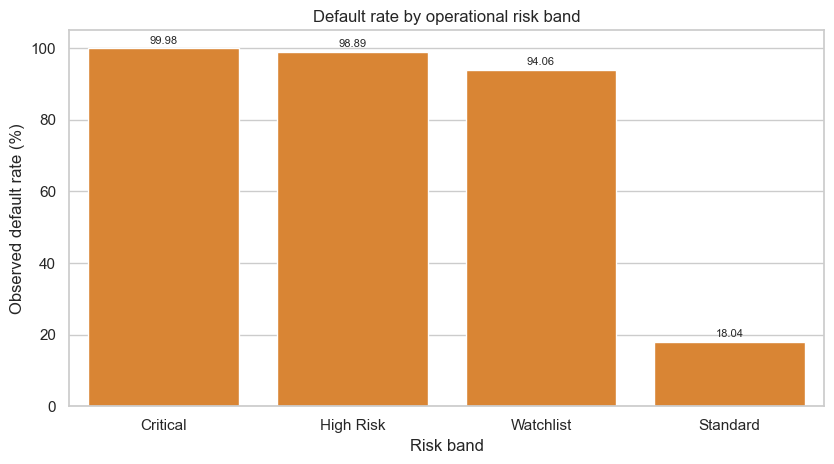

C:\Users\박동하\Documents\Codex\2026-05-04\files-mentioned-by-the-user-amex\amex-credit-risk-portfolio-public\outputs\figures\default_rate_by_risk_band.png


In [3]:
band = read_table("monitoring_bucket_summary.csv")
band["default_rate_pct"] = as_percent(band["default_rate"])
band["capture_share_pct"] = as_percent(band["capture_share"])
band = band.sort_values("avg_risk_score", ascending=False)
display(
    band[
        [
            "risk_band",
            "customer_count",
            "default_count",
            "default_rate_pct",
            "capture_share_pct",
            "avg_risk_score",
            "score_month",
            "model_version",
        ]
    ]
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.barplot(data=band, x="risk_band", y="default_rate_pct", color="#F58518", ax=ax)
ax.set_title("Default rate by operational risk band")
ax.set_xlabel("Risk band")
ax.set_ylabel("Observed default rate (%)")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
path = save_figure("default_rate_by_risk_band.png")
plt.show()
print(path)


`Critical`과 `High` 밴드에 default가 집중된다. 이 결과는 모델 점수를 단순 예측값으로 끝내지 않고, 운영 가능한 review band로 변환할 수 있음을 보여준다.


## Cumulative capture
### 누적 포착률

review scope를 넓힐수록 default를 얼마나 더 포착하는지 확인한다.


,review_scope,review_count,captured_defaults,capture_rate,default_rate_among_reviewed,capture_rate_pct,default_rate_among_reviewed_pct
0,10,45891,44325,0.373018,0.965876,37.30,96.59
1,20,91783,81176,0.683139,0.884434,68.31,88.44
2,30,137674,105116,0.884606,0.763514,88.46,76.35
3,40,183565,115239,0.969797,0.627783,96.98,62.78
4,50,229456,117788,0.991248,0.513336,99.12,51.33
5,60,275348,118450,0.996819,0.430183,99.68,43.02
6,70,321239,118669,0.998662,0.369410,99.87,36.94
7,80,367130,118765,0.999470,0.323496,99.95,32.35
8,90,413022,118810,0.999849,0.287660,99.98,28.77
9,100,458913,118828,1.000000,0.258934,100.00,25.89


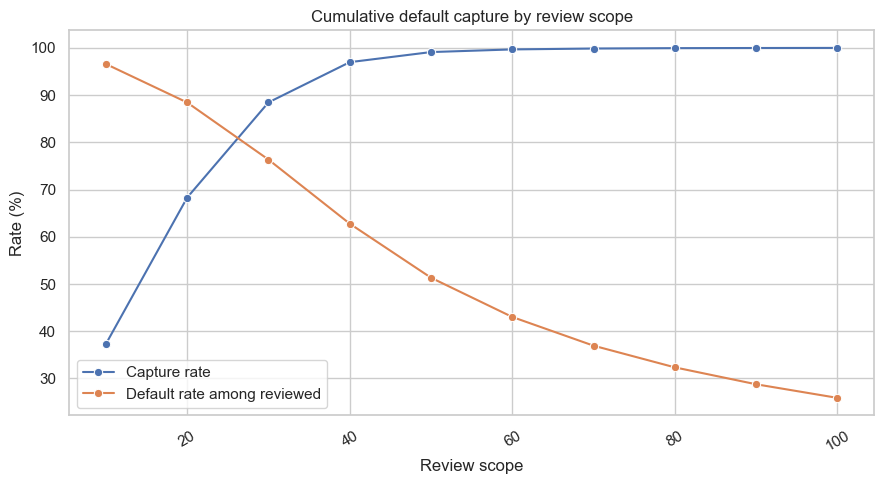

C:\Users\박동하\Documents\Codex\2026-05-04\files-mentioned-by-the-user-amex\amex-credit-risk-portfolio-public\outputs\figures\top10_to_top100_cumulative_summary.png


In [4]:
cumulative = read_table("top10_to_top100_cumulative_summary.csv")
cumulative["capture_rate_pct"] = as_percent(cumulative["capture_rate"])
cumulative["default_rate_among_reviewed_pct"] = as_percent(cumulative["default_rate_among_reviewed"])
display(cumulative)

fig, ax1 = plt.subplots(figsize=(9, 5))
sns.lineplot(data=cumulative, x="review_scope", y="capture_rate_pct", marker="o", ax=ax1, label="Capture rate")
sns.lineplot(data=cumulative, x="review_scope", y="default_rate_among_reviewed_pct", marker="o", ax=ax1, label="Default rate among reviewed")
ax1.set_title("Cumulative default capture by review scope")
ax1.set_xlabel("Review scope")
ax1.set_ylabel("Rate (%)")
ax1.tick_params(axis="x", rotation=30)
ax1.legend()
path = save_figure("top10_to_top100_cumulative_summary.png")
plt.show()
print(path)


상위 구간을 넓히면 포착되는 default 수는 증가하지만, reviewed group 안의 default concentration은 낮아진다. 다음 노트북에서는 이 trade-off를 비용 관점에서 해석한다.
